In [1]:
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# 1) Load data
# ============================================================
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Kaggle dataset paths (House Prices)
df_train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
df_test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

# House Price Prediction


In [2]:
print("hello wold")

hello wold


In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn



In [4]:
# df_train = pd.read_csv('./dataset/train.csv')
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# df_test=pd.read_csv('./dataset/test.csv')
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
df_test.shape

(1459, 80)

In [7]:
df_train.shape

(1460, 81)

In [8]:
df_train_x=df_train.drop(['SalePrice'],axis=1)

In [9]:
df_train_x.shape

(1460, 80)

In [10]:
# df=df_train_x+df_test

df = pd.concat([df_train_x, df_test], axis=0, ignore_index=True)




In [11]:
df.shape

(2919, 80)

In [12]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
2918,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal


In [13]:
df.shape

(2919, 80)

In [14]:
df.isna().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      486
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [15]:
df['LotFrontage'].head(20)

0     65.0
1     80.0
2     68.0
3     60.0
4     84.0
5     85.0
6     75.0
7      NaN
8     51.0
9     50.0
10    70.0
11    85.0
12     NaN
13    91.0
14     NaN
15    51.0
16     NaN
17    72.0
18    66.0
19    70.0
Name: LotFrontage, dtype: float64

In [16]:
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].mean())
df['LotFrontage'].head(20)

0     65.000000
1     80.000000
2     68.000000
3     60.000000
4     84.000000
5     85.000000
6     75.000000
7     69.305795
8     51.000000
9     50.000000
10    70.000000
11    85.000000
12    69.305795
13    91.000000
14    69.305795
15    51.000000
16    69.305795
17    72.000000
18    66.000000
19    70.000000
Name: LotFrontage, dtype: float64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2919 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [18]:
df['Alley'].value_counts()

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [19]:
df['Alley'].head(100)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
95    NaN
96    NaN
97    NaN
98    NaN
99    NaN
Name: Alley, Length: 100, dtype: object

In [20]:
df['Alley']=df['Alley'].fillna('No alley access')
df['Alley'].head(100)

0     No alley access
1     No alley access
2     No alley access
3     No alley access
4     No alley access
           ...       
95    No alley access
96    No alley access
97    No alley access
98    No alley access
99    No alley access
Name: Alley, Length: 100, dtype: object

In [21]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,...,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,...,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737
std,842.787043,42.517628,21.312345,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,...,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,730.500000,20.000000,60.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,...,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,1460.000000,50.000000,69.305795,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,...,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2189.500000,70.000000,78.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,...,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2919 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          2919 non-null   object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [23]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

<Axes: >

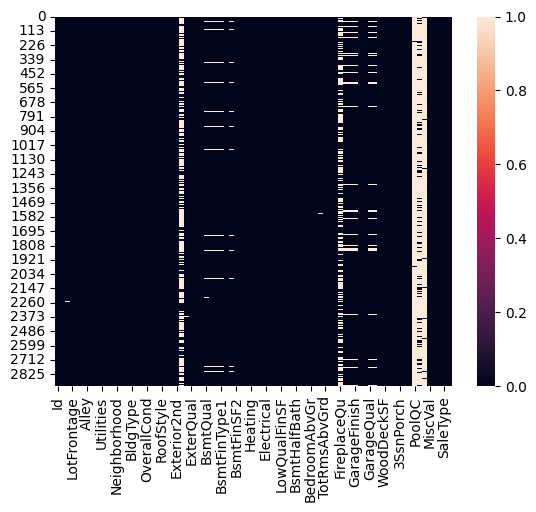

In [24]:
sns.heatmap(df.isna())

In [25]:
df.isna().sum().sum()

12500

In [26]:
df['MiscVal'].isna().sum()

0

In [27]:
df['FireplaceQu'].isna().sum()

1420

In [28]:
df['BsmtFinSF2'].isna().sum()

1

In [29]:
df['Exterior2nd'].isna().sum()

1

In [30]:
df['Fence'].isna().sum()

2348

In [31]:
# df=df.drop(['],axis=1)

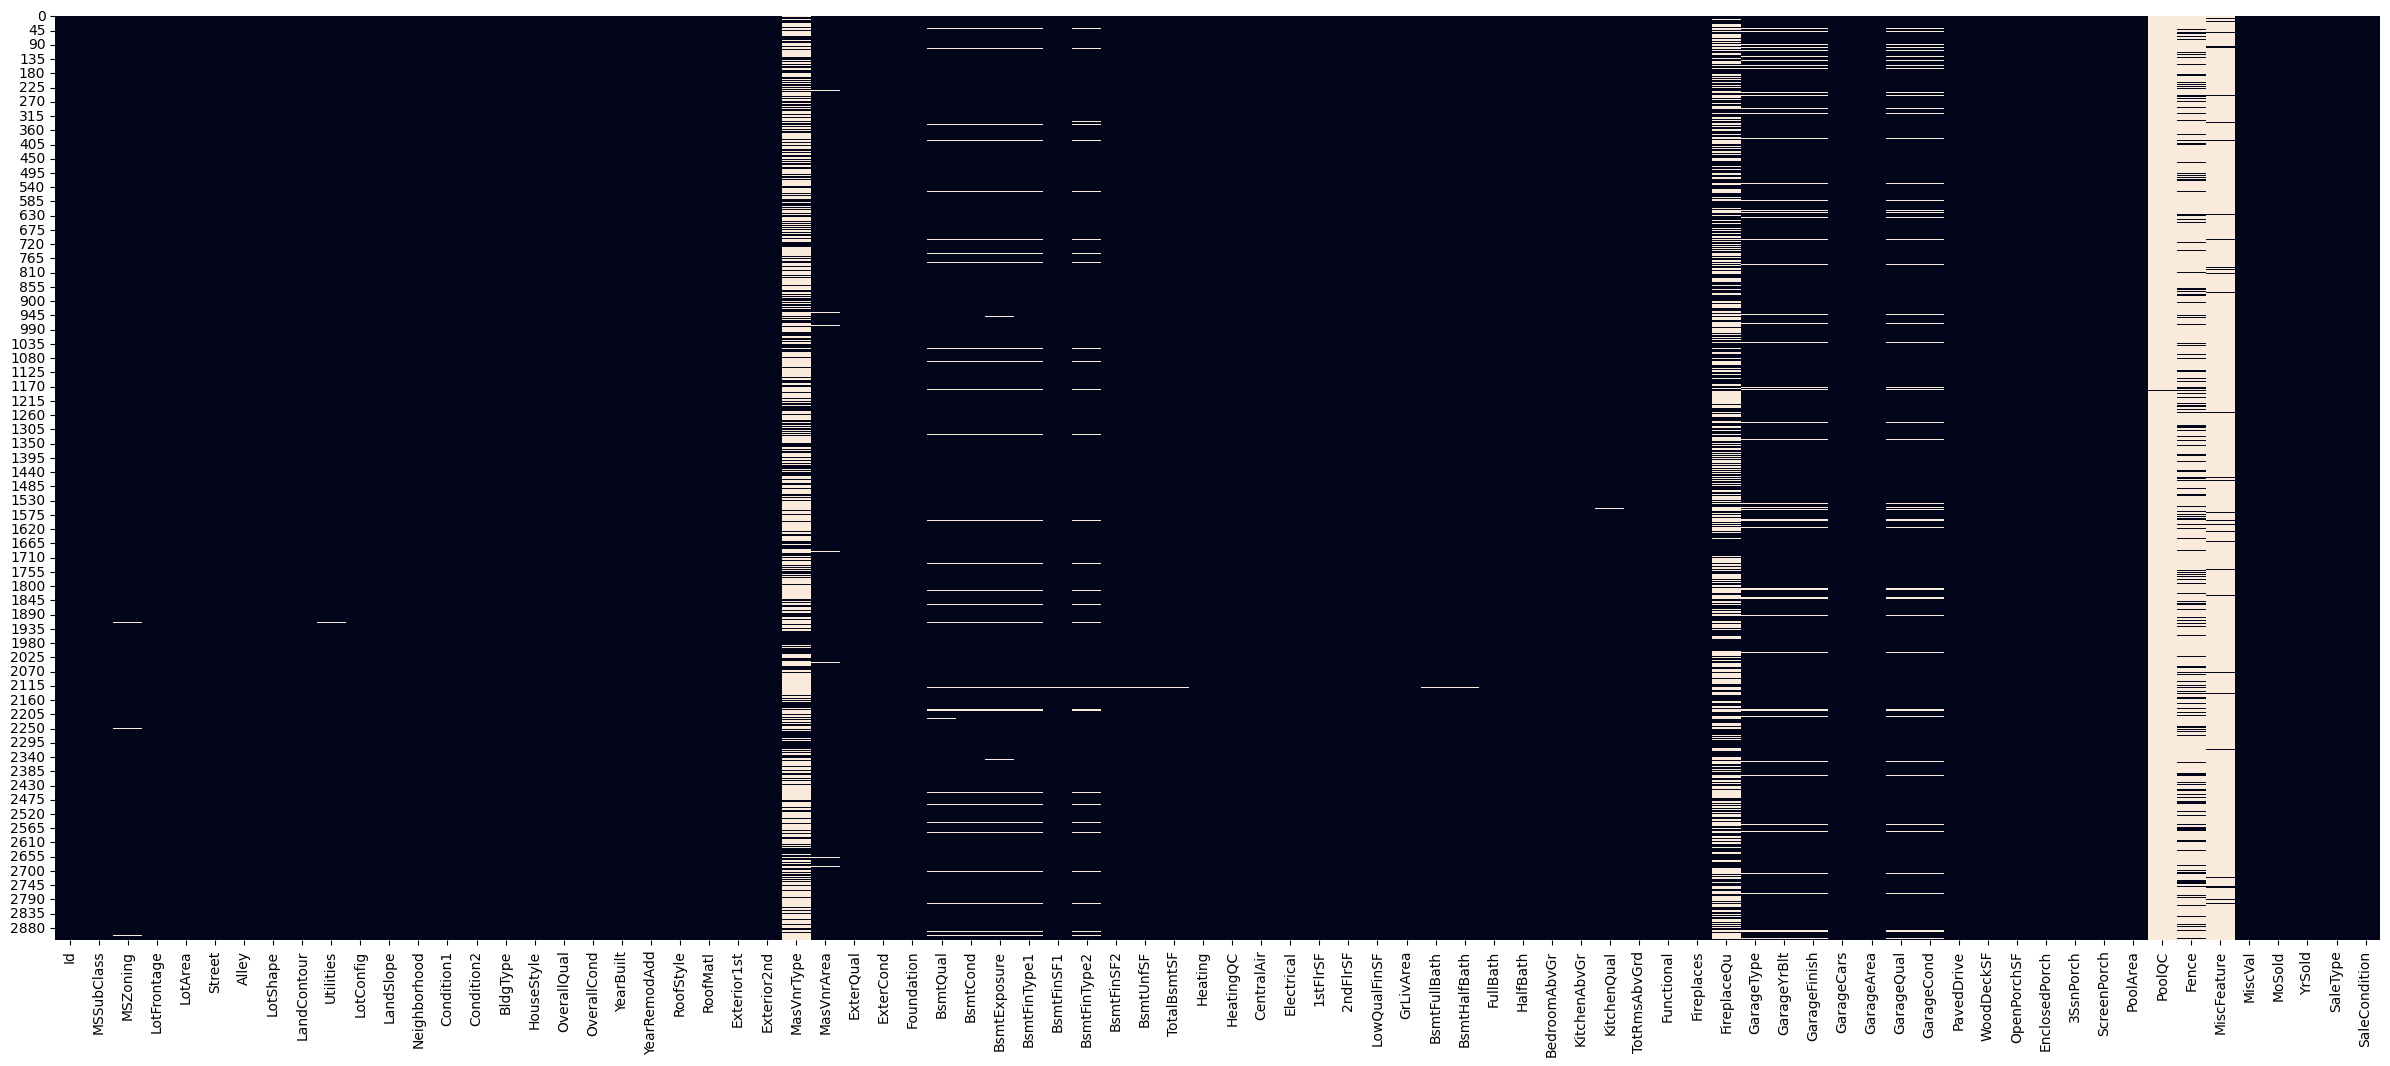

In [32]:
plt.figure(figsize=(30, 12))  # increase width for many columns

sns.heatmap(df.isna(),cbar=False)
plt.show()

In [33]:
df['MiscFeature'].isna().sum()

2814

In [34]:
df['Fence'].isna().sum()

2348

In [35]:
df['MiscVal'].isna().sum()

0

In [36]:
df['MasVnrType'].isna().sum()

1766

In [37]:
df['GarageQual'].isna().sum()

159

In [38]:
df['BsmtFinSF2'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2914    0.0
2915    0.0
2916    0.0
2917    0.0
2918    0.0
Name: BsmtFinSF2, Length: 2919, dtype: float64>

<Axes: xlabel='BsmtFinSF2', ylabel='Count'>

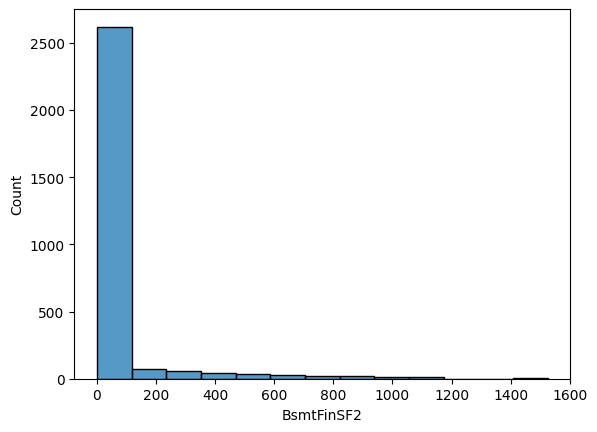

In [39]:
import seaborn as sns
sns.histplot(df['BsmtFinSF2'])


In [40]:
df['BsmtFinSF2'].tail()

2914    0.0
2915    0.0
2916    0.0
2917    0.0
2918    0.0
Name: BsmtFinSF2, dtype: float64

In [41]:
df["MasVnrType"]=df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])

In [42]:
df['GarageYrBlt'].describe


<bound method NDFrame.describe of 0       2003.0
1       1976.0
2       2001.0
3       1998.0
4       2000.0
         ...  
2914       NaN
2915    1970.0
2916    1960.0
2917       NaN
2918    1993.0
Name: GarageYrBlt, Length: 2919, dtype: float64>

In [43]:
df=df.drop(['MasVnrType','PoolQC','Fence','MiscFeature','Id','FireplaceQu','PoolQC'],axis=1)

In [44]:
df['GarageYrBlt']=df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean())

In [45]:
df['GarageYrBlt'].isna().sum()

0

In [46]:
df['GarageType'].isna().sum()

157

In [47]:
df['GarageFinish'].isna().sum()

159

In [48]:
df['GarageType'].value_counts()

GarageType
Attchd     1723
Detchd      779
BuiltIn     186
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64

In [49]:
df['GarageType']=df['GarageType'].fillna(df['GarageType'].mode()[0])
df['GarageFinish']=df['GarageFinish'].fillna(df['GarageFinish'].mode()[0])
df['GarageQual']=df['GarageQual'].fillna(df['GarageQual'].mode()[0])
df['GarageCond']=df['GarageCond'].fillna(df['GarageCond'].mode()[0])

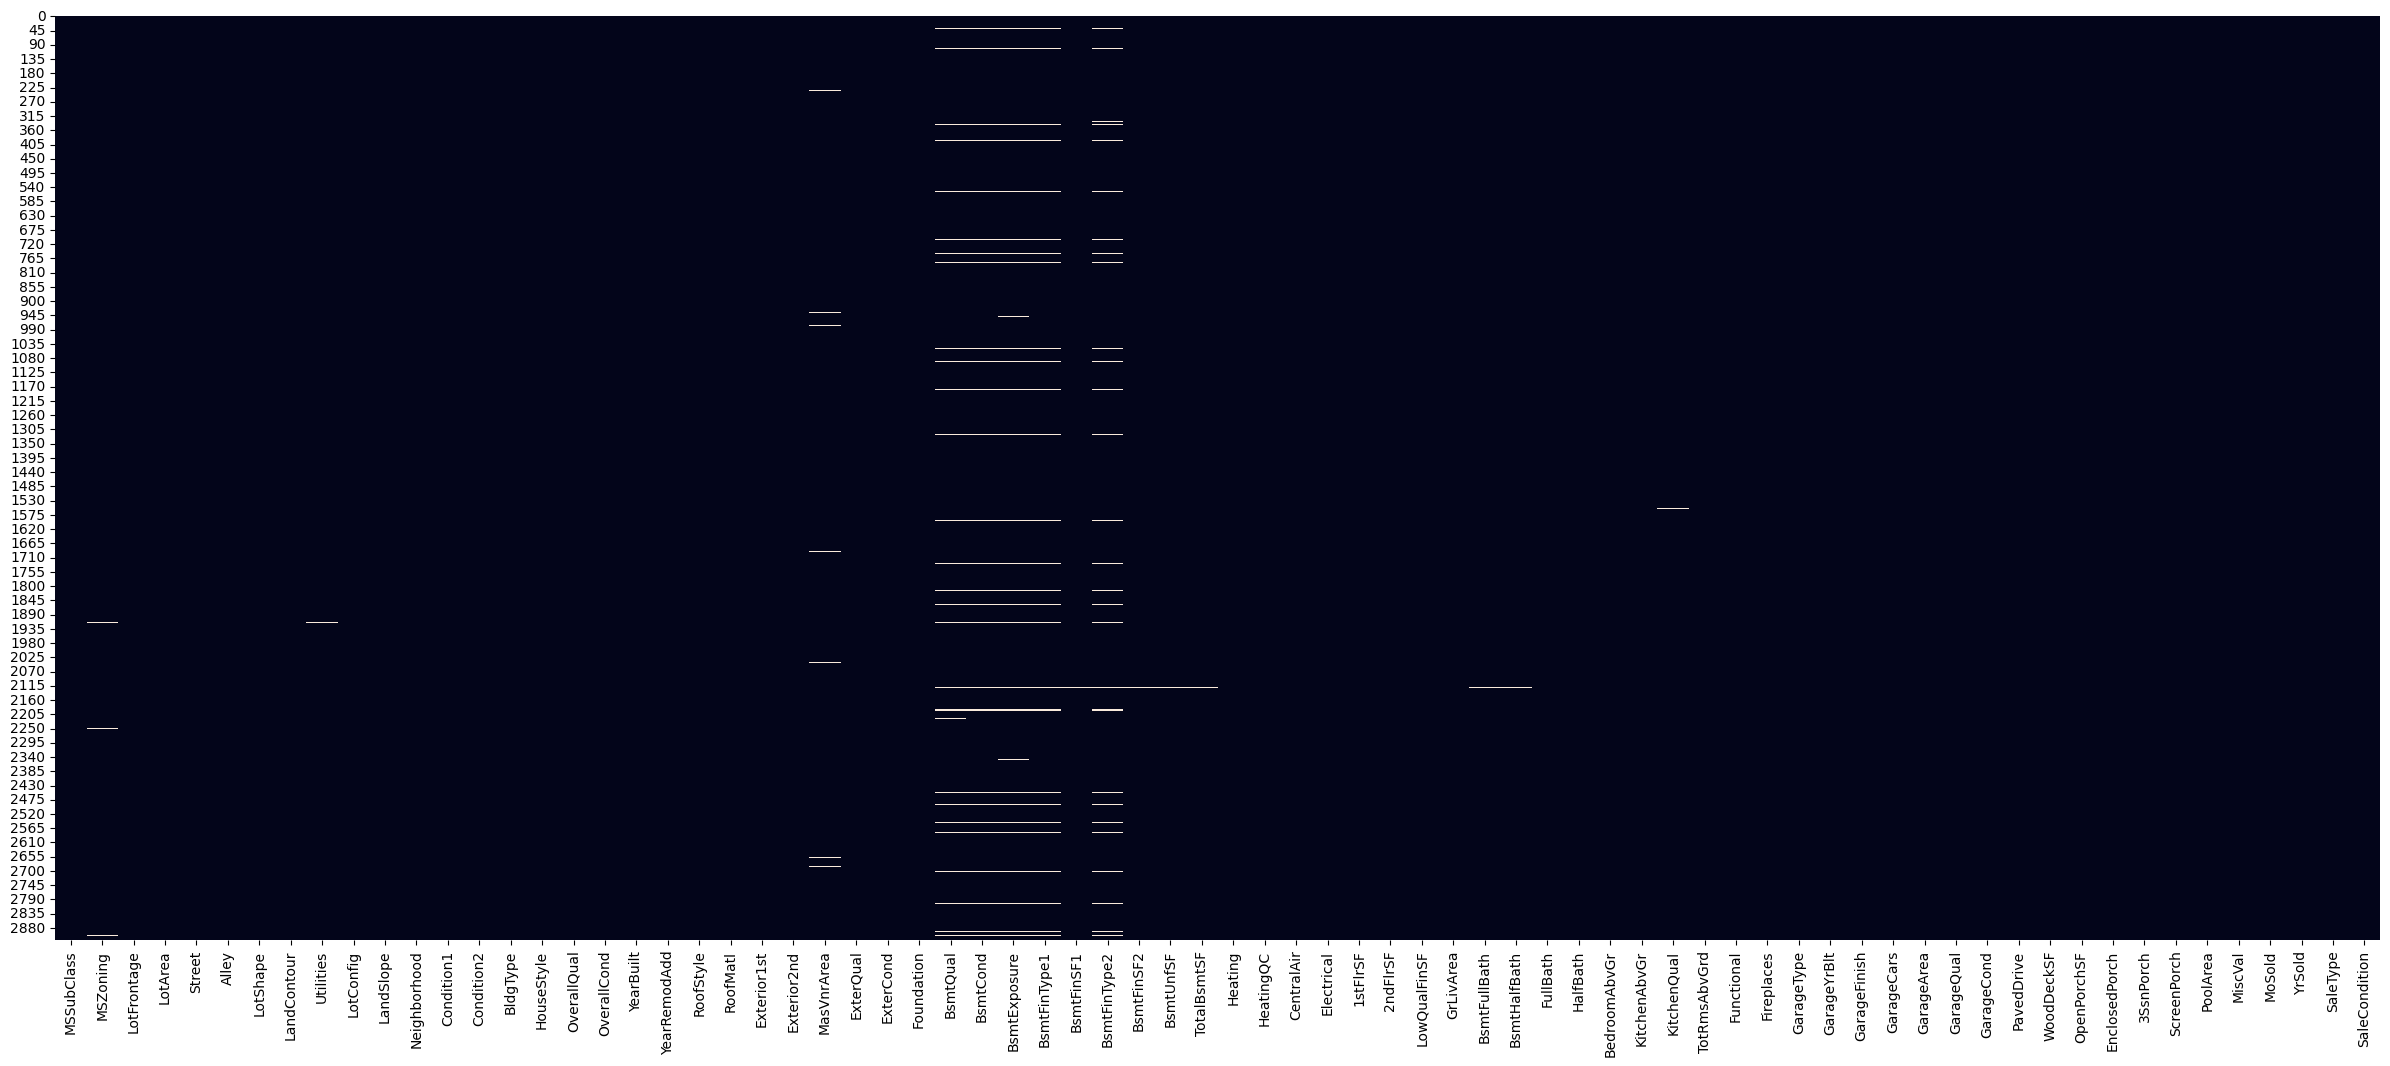

In [50]:
plt.figure(figsize=(30, 12))  # increase width for many columns
sns.heatmap(df.isna(),cbar=False)
plt.show()

In [51]:
df['GarageQual'].value_counts()

GarageQual
TA    2763
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64

In [52]:
df['GarageQual'].isna().sum()

0

In [53]:
df['GarageQual'].value_counts()

GarageQual
TA    2763
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64

In [54]:
df['GarageCond'].value_counts()

GarageCond
TA    2813
Fa      74
Gd      15
Po      14
Ex       3
Name: count, dtype: int64

In [55]:
df['GarageCond'].isna().sum()

0

In [56]:
df['MasVnrArea'].isna().sum()

23

In [57]:
df['MasVnrArea'].value_counts

<bound method IndexOpsMixin.value_counts of 0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
2914      0.0
2915      0.0
2916      0.0
2917      0.0
2918     94.0
Name: MasVnrArea, Length: 2919, dtype: float64>

In [58]:
df['MasVnrArea'].head(20)

0     196.0
1       0.0
2     162.0
3       0.0
4     350.0
5       0.0
6     186.0
7     240.0
8       0.0
9       0.0
10      0.0
11    286.0
12      0.0
13    306.0
14    212.0
15      0.0
16    180.0
17      0.0
18      0.0
19      0.0
Name: MasVnrArea, dtype: float64

In [59]:
df['MasVnrArea']=df['MasVnrArea'].fillna(df['MasVnrArea'].mode()[0])

In [60]:
df['MasVnrArea'].isna().sum()

0

In [61]:
df['Electrical'].isna().sum()

1

In [62]:
# df.dropna(subset=['Electrical'], inplace=True)
# Instead of dropping, fill with mode
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])


In [63]:
df['Electrical'].isna().sum()

0

In [64]:
df['BsmtFinType1'].isna().sum()

79

In [65]:
df['BsmtFinType1'].value_counts

<bound method IndexOpsMixin.value_counts of 0       GLQ
1       ALQ
2       GLQ
3       ALQ
4       GLQ
       ... 
2914    Unf
2915    Rec
2916    ALQ
2917    GLQ
2918    LwQ
Name: BsmtFinType1, Length: 2919, dtype: object>

In [66]:
df['BsmtFinType2'].isna().sum()

80

In [67]:
df['BsmtFinType2'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Unf
1       Unf
2       Unf
3       Unf
4       Unf
       ... 
2914    Unf
2915    Unf
2916    Unf
2917    Unf
2918    Unf
Name: BsmtFinType2, Length: 2919, dtype: object>

In [68]:
df['BsmtQual'].isna().sum()

81

In [69]:
df['BsmtQual'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Gd
1       Gd
2       Gd
3       TA
4       Gd
        ..
2914    TA
2915    TA
2916    TA
2917    Gd
2918    Gd
Name: BsmtQual, Length: 2919, dtype: object>

In [70]:
df['BsmtCond'].isna().sum()

82

In [71]:
df['BsmtCond'].value_counts

<bound method IndexOpsMixin.value_counts of 0       TA
1       TA
2       TA
3       Gd
4       TA
        ..
2914    TA
2915    TA
2916    TA
2917    TA
2918    TA
Name: BsmtCond, Length: 2919, dtype: object>

In [72]:
df['BsmtHalfBath'].isna().sum()

2

In [73]:
df['BsmtHalfBath'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0.0
1       1.0
2       0.0
3       0.0
4       0.0
       ... 
2914    0.0
2915    0.0
2916    0.0
2917    1.0
2918    0.0
Name: BsmtHalfBath, Length: 2919, dtype: float64>

In [74]:
mean_columns=['GarageArea','BsmtFinSF1','BsmtUnfSF','TotalBsmtSF']

for i,mean_column in enumerate(mean_columns):
    df[mean_column]=df[mean_column].fillna(df[mean_column].mean())
    
# bro u can use this :
# cols = ['BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtExposure']

# df[cols] = df[cols].fillna(df[cols].mode().iloc[0])


In [75]:
mode_columns=['Utilities','BsmtFinSF2','SaleType','BsmtFinType1','BsmtFinType2','BsmtQual','BsmtCond','BsmtExposure','MSZoning','Exterior1st','Exterior2nd','BsmtFullBath','BsmtHalfBath','Functional','GarageCars','KitchenQual']

for i,made_column in enumerate(mode_columns):
    df[made_column]=df[made_column].fillna(df[made_column].mode()[0])
    
# bro u can use this :
# cols = ['BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtExposure']

# df[cols] = df[cols].fillna(df[cols].mode().iloc[0])


In [76]:
df['KitchenQual'].isna().sum() 

0

In [77]:
df['KitchenQual'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Gd
1       TA
2       Gd
3       Gd
4       Gd
        ..
2914    TA
2915    TA
2916    TA
2917    TA
2918    TA
Name: KitchenQual, Length: 2919, dtype: object>

In [78]:
df['BsmtFullBath'].value_counts #mode

<bound method IndexOpsMixin.value_counts of 0       1.0
1       0.0
2       1.0
3       1.0
4       1.0
       ... 
2914    0.0
2915    0.0
2916    1.0
2917    0.0
2918    0.0
Name: BsmtFullBath, Length: 2919, dtype: float64>

In [79]:
df['BsmtFullBath'].value_counts #mode

<bound method IndexOpsMixin.value_counts of 0       1.0
1       0.0
2       1.0
3       1.0
4       1.0
       ... 
2914    0.0
2915    0.0
2916    1.0
2917    0.0
2918    0.0
Name: BsmtFullBath, Length: 2919, dtype: float64>

In [80]:
df['GarageArea'].isna().sum() #mean

0

In [81]:
df['GarageArea'].value_counts

<bound method IndexOpsMixin.value_counts of 0       548.0
1       460.0
2       608.0
3       642.0
4       836.0
        ...  
2914      0.0
2915    286.0
2916    576.0
2917      0.0
2918    650.0
Name: GarageArea, Length: 2919, dtype: float64>

In [82]:
df['Functional'].isna().sum()

0

In [83]:
df['Functional'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Typ
1       Typ
2       Typ
3       Typ
4       Typ
       ... 
2914    Typ
2915    Typ
2916    Typ
2917    Typ
2918    Typ
Name: Functional, Length: 2919, dtype: object>

In [84]:
df['MSZoning'].isna().sum()

0

In [85]:
df['MSZoning'].value_counts

<bound method IndexOpsMixin.value_counts of 0       RL
1       RL
2       RL
3       RL
4       RL
        ..
2914    RM
2915    RM
2916    RL
2917    RL
2918    RL
Name: MSZoning, Length: 2919, dtype: object>

In [86]:
df['Exterior2nd'].isna().sum()

0

In [87]:
df['Exterior2nd'].value_counts

<bound method IndexOpsMixin.value_counts of 0       VinylSd
1       MetalSd
2       VinylSd
3       Wd Shng
4       VinylSd
         ...   
2914    CmentBd
2915    CmentBd
2916    VinylSd
2917    Wd Shng
2918    HdBoard
Name: Exterior2nd, Length: 2919, dtype: object>

In [88]:
df['BsmtFinSF1'].isna().sum()

0

In [89]:
df['BsmtFinSF1'].value_counts # mean

<bound method IndexOpsMixin.value_counts of 0        706.0
1        978.0
2        486.0
3        216.0
4        655.0
         ...  
2914       0.0
2915     252.0
2916    1224.0
2917     337.0
2918     758.0
Name: BsmtFinSF1, Length: 2919, dtype: float64>

In [90]:
df['BsmtUnfSF'].isna().sum()

0

In [91]:
df['BsmtUnfSF'].value_counts #mean

<bound method IndexOpsMixin.value_counts of 0       150.0
1       284.0
2       434.0
3       540.0
4       490.0
        ...  
2914    546.0
2915    294.0
2916      0.0
2917    575.0
2918    238.0
Name: BsmtUnfSF, Length: 2919, dtype: float64>

In [92]:
df['TotalBsmtSF'].isna().sum()

0

In [93]:
df['TotalBsmtSF'].value_counts #mean

<bound method IndexOpsMixin.value_counts of 0        856.0
1       1262.0
2        920.0
3        756.0
4       1145.0
         ...  
2914     546.0
2915     546.0
2916    1224.0
2917     912.0
2918     996.0
Name: TotalBsmtSF, Length: 2919, dtype: float64>

In [94]:
df['Utilities'].isna().sum()

0

In [95]:
df['Utilities'].value_counts()

Utilities
AllPub    2918
NoSeWa       1
Name: count, dtype: int64

In [96]:
df['BsmtHalfBath'].isna().sum()

0

In [97]:
df['Utilities'].isna().sum()

0

In [98]:
df['BsmtFinSF2'].head(20)

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
5      0.0
6      0.0
7     32.0
8      0.0
9      0.0
10     0.0
11     0.0
12     0.0
13     0.0
14     0.0
15     0.0
16     0.0
17     0.0
18     0.0
19     0.0
Name: BsmtFinSF2, dtype: float64

In [99]:
skewness = df.skew(numeric_only=True)
skewness[abs(skewness) > 1]  # high skew


MSSubClass        1.376165
LotFrontage       1.646420
LotArea          12.829025
MasVnrArea        2.614936
BsmtFinSF1        1.425966
BsmtFinSF2        4.148275
TotalBsmtSF       1.163082
1stFlrSF          1.470360
LowQualFinSF     12.094977
GrLivArea         1.270010
BsmtHalfBath      3.933616
KitchenAbvGr      4.304467
WoodDeckSF        1.843380
OpenPorchSF       2.536417
EnclosedPorch     4.005950
3SsnPorch        11.381914
ScreenPorch       3.948723
PoolArea         16.907017
MiscVal          21.958480
dtype: float64

In [100]:
import numpy as np

log_cols = ['LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
            '1stFlrSF','WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch']

for col in log_cols:
    df[col] = np.log1p(df[col])


In [101]:
skewness = df.skew(numeric_only=True)
skewness[abs(skewness) > 1]  # high skew


MSSubClass        1.376165
LotFrontage      -1.019985
BsmtFinSF2        2.463749
TotalBsmtSF       1.163082
LowQualFinSF     12.094977
GrLivArea         1.270010
BsmtHalfBath      3.933616
KitchenAbvGr      4.304467
EnclosedPorch     1.962089
3SsnPorch         8.829794
ScreenPorch       2.947420
PoolArea         16.907017
MiscVal          21.958480
dtype: float64

In [102]:
df['Has_PoolArea'] = (df['PoolArea'] > 0).astype(int)
df.drop(columns=['PoolArea'], inplace=True)


In [103]:
df['Has_MiscVal'] = (df['MiscVal'] > 0).astype(int)
df.drop(columns=['MiscVal'], inplace=True)


In [104]:
df['Has_MiscVal'].head()

0    0
1    0
2    0
3    0
4    0
Name: Has_MiscVal, dtype: int64

In [105]:
# import numpy as np

# # Columns to log-transform (continuous + positive)
# log_cols = ['BsmtFinSF2', 'ScreenPorch', 'EnclosedPorch']

# for col in log_cols:
#     df[col] = np.log1p(df[col])

# # Columns to convert to binary (mostly 0s)
# binary_cols = ['LowQualFinSF', '3SsnPorch', 'PoolArea', 'MiscVal']

# for col in binary_cols:
#     df[f'Has_{col}'] = (df[col] > 0).astype(int)
#     df.drop(columns=[col], inplace=True)


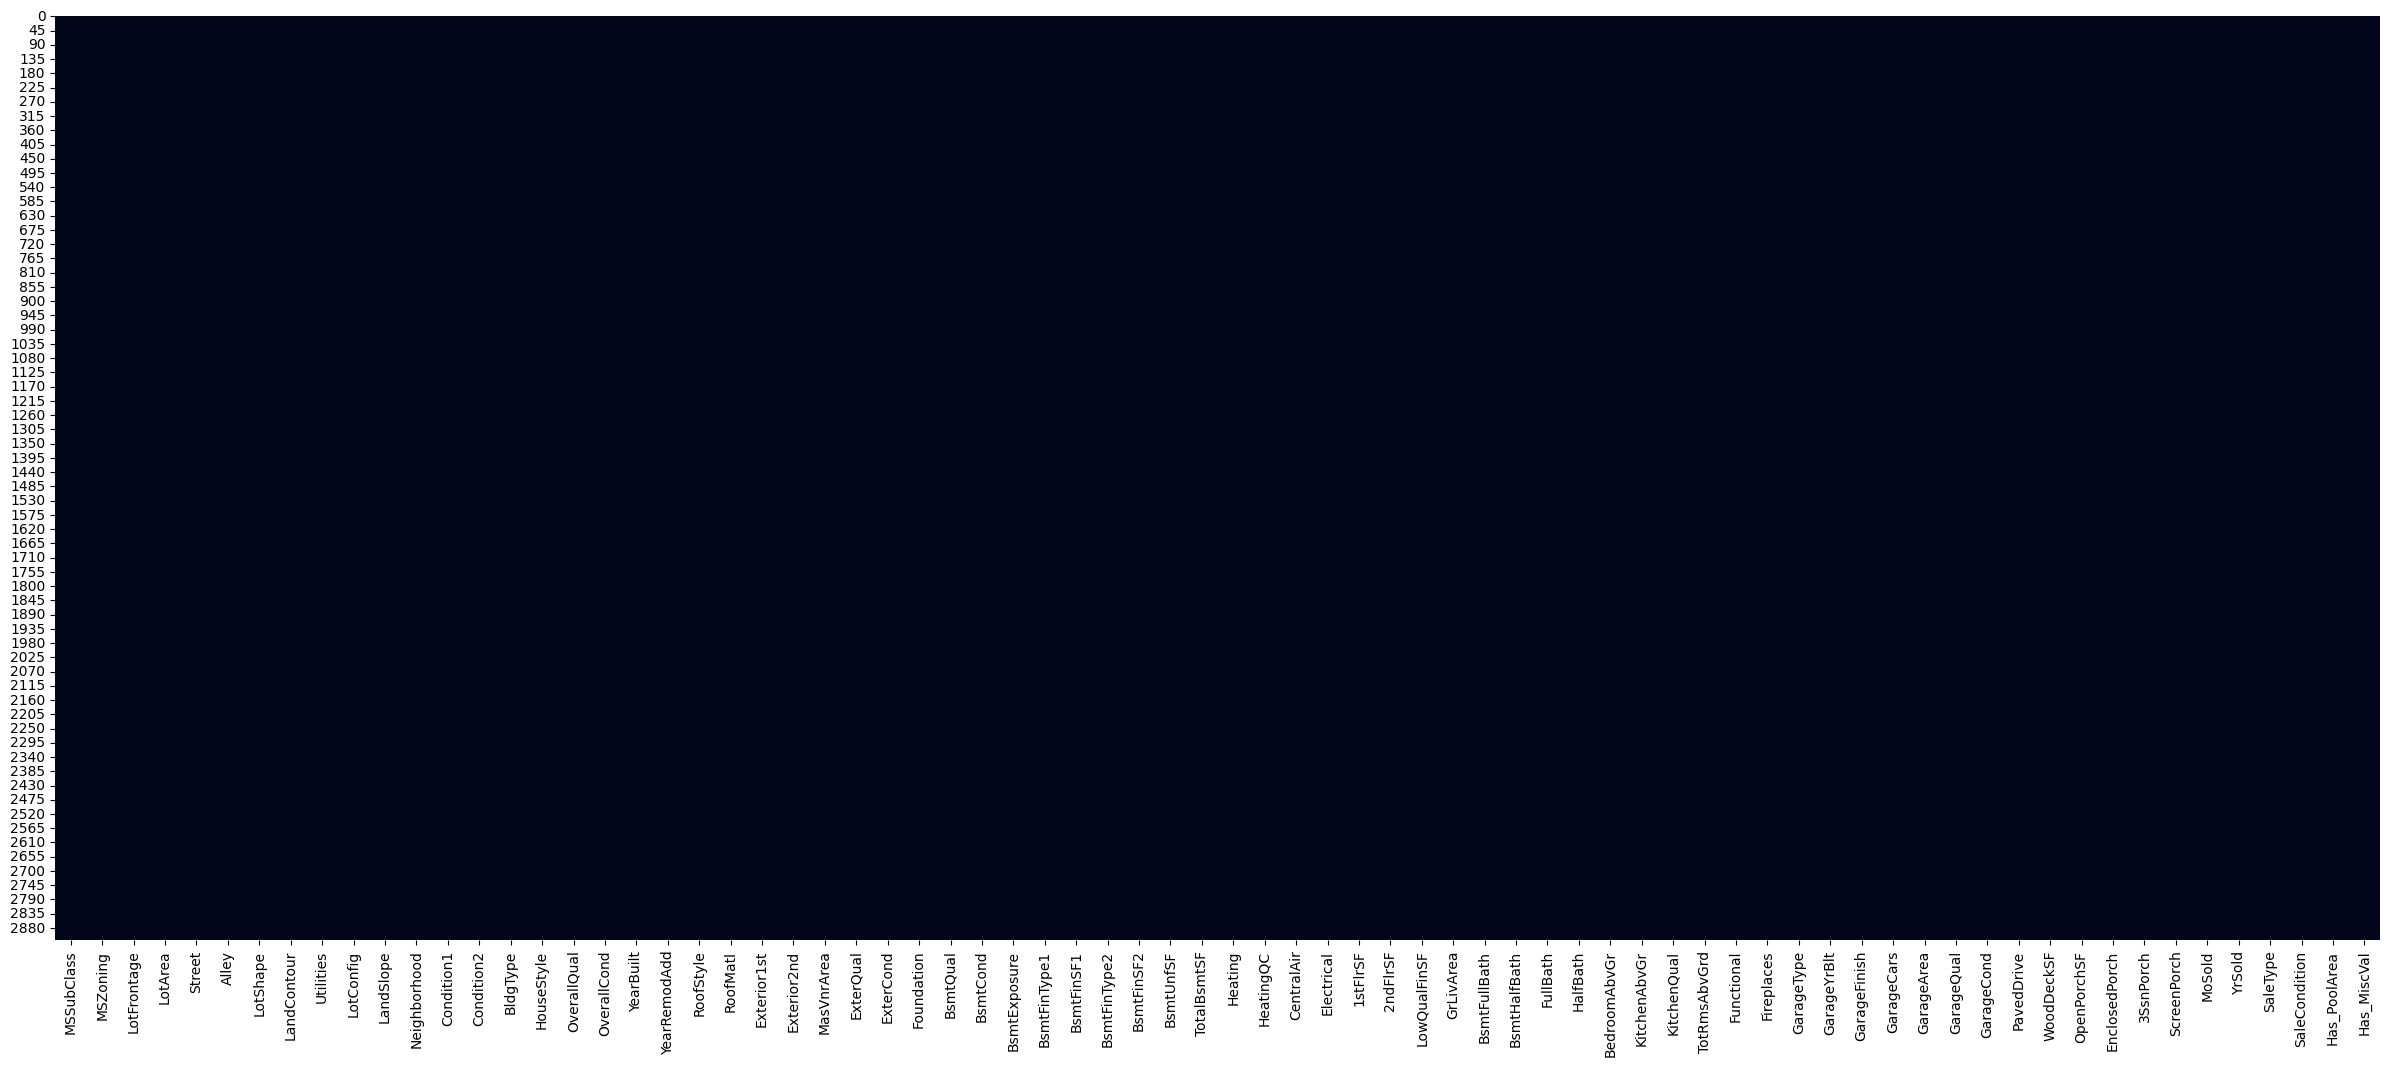

In [106]:
plt.figure(figsize=(30, 12))  # increase width for many columns
sns.heatmap(df.isna(),cbar=False)
plt.show()

## Data cleaning finished

In [107]:


# # pairplot shows relationship between all numeric columns
# sns.pairplot(df)

# plt.show()

In [108]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,MoSold,YrSold,SaleType,SaleCondition,Has_PoolArea,Has_MiscVal
0,60,RL,4.189655,9.042040,Pave,No alley access,Reg,Lvl,AllPub,Inside,...,4.127134,0.000000,0.0,0.0,2,2008,WD,Normal,0,0
1,20,RL,4.394449,9.169623,Pave,No alley access,Reg,Lvl,AllPub,FR2,...,0.000000,0.000000,0.0,0.0,5,2007,WD,Normal,0,0
2,60,RL,4.234107,9.328212,Pave,No alley access,IR1,Lvl,AllPub,Inside,...,3.761200,0.000000,0.0,0.0,9,2008,WD,Normal,0,0
3,70,RL,4.110874,9.164401,Pave,No alley access,IR1,Lvl,AllPub,Corner,...,3.583519,5.609472,0.0,0.0,2,2006,WD,Abnorml,0,0
4,60,RL,4.442651,9.565284,Pave,No alley access,IR1,Lvl,AllPub,FR2,...,4.442651,0.000000,0.0,0.0,12,2008,WD,Normal,0,0


In [109]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,MoSold,YrSold,SaleType,SaleCondition,Has_PoolArea,Has_MiscVal
0,60,RL,4.189655,9.042040,Pave,No alley access,Reg,Lvl,AllPub,Inside,...,4.127134,0.000000,0.0,0.0,2,2008,WD,Normal,0,0
1,20,RL,4.394449,9.169623,Pave,No alley access,Reg,Lvl,AllPub,FR2,...,0.000000,0.000000,0.0,0.0,5,2007,WD,Normal,0,0
2,60,RL,4.234107,9.328212,Pave,No alley access,IR1,Lvl,AllPub,Inside,...,3.761200,0.000000,0.0,0.0,9,2008,WD,Normal,0,0
3,70,RL,4.110874,9.164401,Pave,No alley access,IR1,Lvl,AllPub,Corner,...,3.583519,5.609472,0.0,0.0,2,2006,WD,Abnorml,0,0
4,60,RL,4.442651,9.565284,Pave,No alley access,IR1,Lvl,AllPub,FR2,...,4.442651,0.000000,0.0,0.0,12,2008,WD,Normal,0,0


In [110]:
import pandas as pd

# assume df is your dataset
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MoSold', 'YrSold', 'Has_PoolArea', 'Has_MiscVal']
Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'Garage

In [111]:
df['GrLivArea_log']=np.log(df['GrLivArea'])

In [112]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'En

In [113]:
df['TotalBath'] = df['FullBath'] + 0.5*df['HalfBath']


In [114]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'En

In [115]:
df.shape


(2919, 76)

In [116]:
df_trainDataset_y=df_train['SalePrice']
df_trainDataset_y.shape


(1460,)

In [117]:
df_trainDataset_x=df[:1460]
df_testDataset_x=df[1460:]

In [118]:
df_testDataset_x.shape

(1459, 76)

In [119]:
df_trainDataset_x.shape

(1460, 76)

In [120]:

#turn the category into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features=['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
one_hot=OneHotEncoder()
transformer=ColumnTransformer([("one_hot",one_hot,categorical_features)],
                              remainder="passthrough")

transformed_trainDataset_x= transformer.fit_transform(df_trainDataset_x)
transformed_testDataset_x= transformer.transform(df_testDataset_x)

transformed_trainDataset_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 93585 stored elements and shape (1460, 271)>

In [121]:


from sklearn.model_selection import train_test_split

np.random.seed(90)

x_train,x_test,y_train,y_test=train_test_split(transformed_trainDataset_x,df_trainDataset_y,test_size=0.1)
from sklearn.ensemble import RandomForestRegressor

RFModel=RandomForestRegressor(n_estimators=300,
                              
                              max_depth=None,  # let tree grow fully
                              min_samples_leaf=2,
                              random_state=90,
                              n_jobs=-1 )
RFModel.fit(x_train,y_train)
RFModel.score(x_test,y_test)

0.840717571762451

In [122]:
x_train.shape

(1314, 271)

In [123]:
# from sklearn.ensemble import RandomForestRegressor

# RFModel=RandomForestRegressor()
# RFModel.fit(x_train,x_test)

In [124]:
y_preds=RFModel.predict(x_test)
y_preds

array([133900.59877646, 123548.74189153,  91362.19775661, 168926.68880159,
       277097.59158466, 126689.49331217, 106638.06556878, 103978.03248413,
       225011.51641005, 160020.51754762, 333418.32247475, 151075.08049735,
       195836.10194889, 265755.05849074, 112600.33880952, 119658.19878307,
       222901.59547619, 236706.94083069, 126579.62924206, 227675.3516455 ,
       126292.28837302, 189337.89446561, 132823.36771164, 353905.15777778,
       405679.72636905, 165097.1247381 , 188609.23557095, 191530.21455014,
       141776.59441799, 147441.47726984, 128053.14996296, 264361.42853704,
       178198.57431602,  88145.98274603, 114878.00147619, 196937.49157407,
       238121.79616402, 136303.77038624, 278225.31345503, 143180.13966402,
       154177.3342809 , 166031.40144949, 162883.69618519, 412039.71562302,
       173697.68774074, 205808.65598677, 173409.35496032, 151585.31662434,
       138001.73716667, 149810.32365079, 307071.97583201, 145680.68162698,
       195918.94070455, 1

In [125]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_preds)



1024412972.894836

In [126]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_preds)


20204.48399758048

In [127]:
from sklearn.linear_model import LinearRegression

LRModel=LinearRegression()
LRModel.fit(x_train,y_train)
LRModel.score(x_test,y_test)

0.894866664578907

In [128]:
LRy_preds=LRModel.predict(x_test)

In [129]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,LRy_preds)


676157149.7921381

In [130]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,LRy_preds)

16604.39644765325

In [131]:
# Necessary imports
import numpy as np
import pandas as pd
import xgboost as xg
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as MSE



# Instantiation
XGModel = xg.XGBRegressor(
    objective='reg:squarederror',  # use squared error for regression
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=223
)
# Fitting the model
XGModel.fit(x_train, y_train)

# Predict the model
XG_preds = XGModel.predict(x_test)

# # RMSE Computation
# rmse = np.sqrt(MSE(y_test,XG_preds))
# print(rmse)


In [132]:
# # Necessary imports
# import numpy as np
# import pandas as pd
# import xgboost as xg
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error as MSE



# # Instantiation
# XGModel = xg.XGBRegressor(objective ='reg:linear',
#                     n_estimators=120, seed = 223)

# # Fitting the model
# XGModel.fit(x_train, y_train)

# # Predict the model
# XG_preds = XGModel.predict(x_test)

# # # RMSE Computation
# # rmse = np.sqrt(MSE(y_test,XG_preds))
# # print(rmse)

In [133]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,XG_preds)

17894.131421232876

In [134]:
XGModel.score(x_test, y_test)


0.8660588378160385

In [135]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,XG_preds)


861432523.7510126

# mODel test accuracy on different model


In [136]:

transformed_testDataset_x 

test_LR_preds=LRModel.predict(transformed_testDataset_x)
test_LR_preds



array([121023.48471372, 163389.31293224, 194807.04305564, ...,
       175016.88242325,  99616.07735865, 222657.98582242])

In [137]:
test_LR_preds

array([121023.48471372, 163389.31293224, 194807.04305564, ...,
       175016.88242325,  99616.07735865, 222657.98582242])

In [138]:
df_test['Id'].shape

(1459,)

In [139]:
test_LR_preds.shape

(1459,)

In [140]:
submission = pd.DataFrame({
    "Id": df_test['Id'],  
    "SalePrice": test_LR_preds   
})

# Save for Kaggle
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv ready with shape:", submission.shape)
submission.head()

✅ submission.csv ready with shape: (1459, 2)


,Id,SalePrice
0,1461,121023.484714
1,1462,163389.312932
2,1463,194807.043056
3,1464,201742.653384
4,1465,200182.261519
